In [ ]:
# import necessary libraries
import math
from collections import defaultdict

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

CONF_WEIGHT = {"High": 3, "Medium": 2, "Low": 1}
CLASSES = ["Anti-immigration", "Non-anti-immigration"]

DATA_PATH = "../SRQ2 comment_annotation_result/comments_immigration_labelled.csv"
df = pd.read_csv(DATA_PATH)
df["parent_id"] = df["parent_id"].where(df["parent_id"].notna(), None)

comment_id_to_author = dict(zip(df["comment_id"], df["author"]))
video_stance_map = (
    df.drop_duplicates("video_id")
      .set_index("video_id")["video_stance"]
      .to_dict()
)


In [ ]:
def majority_class(group):
    labelled = group[group["comment_stance"] != "Other"]
    if labelled.empty:
        return None

    counts = labelled["comment_stance"].value_counts()
    tied = counts[counts == counts.max()].index.tolist()
    if len(tied) == 1:
        return tied[0]

    weighted = {
        cls: labelled.loc[labelled["comment_stance"] == cls, "confidence"]
                    .map(CONF_WEIGHT).sum()
        for cls in tied
    }
    best = max(weighted, key=weighted.get)
    return "Undetermined" if list(weighted.values()).count(weighted[best]) > 1 else best

user_class = (
    df.groupby("author", group_keys=False)
      .apply(majority_class, include_groups=False)
      .to_dict()
)

edges = []
for row in df.itertuples(index=False):
    source = row.author
    if row.is_reply:
        target = comment_id_to_author.get(row.parent_id)
        if target is None or source == target:
            continue
    else:
        target = ("VIDEO", row.video_id)

    edges.append((source, target, row.video_id, row.video_stance))

valid_classes = set(CLASSES)
keep_edges = []

for source, target, video_id, stance in edges:
    if user_class.get(source) not in valid_classes:
        continue
    if isinstance(target, tuple) or user_class.get(target) in valid_classes:
        keep_edges.append((source, target, video_id, stance))

G_main = nx.DiGraph()
for video_id, stance in video_stance_map.items():
    G_main.add_node(("VIDEO", video_id), node_type="hub", stance=stance, cls=None)

for author, cls in user_class.items():
    if cls in valid_classes:
        G_main.add_node(author, node_type="user", cls=cls)

G_main.add_edges_from((source, target) for source, target, _, _ in keep_edges)
G_main.remove_nodes_from(list(nx.isolates(G_main)))


In [ ]:
def build_stance_subnetwork(stance):
    sub_edges = [
        (source, target)
        for source, target, _, video_stance in keep_edges
        if video_stance == stance
    ]

    G = nx.DiGraph()
    for video_id, video_stance in video_stance_map.items():
        if video_stance == stance:
            G.add_node(("VIDEO", video_id), node_type="hub", stance=video_stance, cls=None)

    for node, data in G_main.nodes(data=True):
        if data["node_type"] == "user":
            G.add_node(node, **data)

    G.add_edges_from(sub_edges)
    G.remove_nodes_from(list(nx.isolates(G)))
    return G

def network_stats(G):
    n = G.number_of_nodes()
    degree = dict(G.degree())
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())

    Gu = G.to_undirected()
    largest = max(nx.connected_components(Gu), key=len)
    component = Gu.subgraph(largest)
    diameter = (
        nx.approximation.diameter(component)
        if component.number_of_nodes() > 2000
        else nx.diameter(component)
    )

    return {
        "Nodes": n,
        "Edges": G.number_of_edges(),
        "Avg. degree": round(sum(degree.values()) / n, 3),
        "Diameter": diameter,
        "Density": round(nx.density(G), 6),
        "Max in-degree": max(in_degree.values()),
        "Max out-degree": max(out_degree.values()),
    }

def ei_index(G, classes=CLASSES):
    internal = {cls: 0 for cls in classes}
    external = {cls: 0 for cls in classes}

    for source, target in G.edges():
        source_cls = G.nodes[source].get("cls")
        if source_cls not in classes:
            continue

        if G.nodes[target].get("cls") == source_cls:
            internal[source_cls] += 1
        else:
            external[source_cls] += 1

    results = {}
    for cls in classes:
        I, E = internal[cls], external[cls]
        results[cls] = {
            "internal": I,
            "external": E,
            "class_EI": (E - I) / (E + I) if I + E else np.nan,
        }

    total_I = sum(internal.values())
    total_E = sum(external.values())
    global_ei = (total_E - total_I) / (total_E + total_I)
    return results, global_ei

stance_subnetworks = {
    stance: build_stance_subnetwork(stance)
    for stance in ["Right", "Mainstream"]
}


In [10]:
network_params_table = pd.DataFrame({
    stance: network_stats(G)
    for stance, G in stance_subnetworks.items()
})[["Mainstream", "Right"]]

network_params_table.index.name = "Network parameter"
display(network_params_table)


,Mainstream,Right
Network parameter,,
Nodes,2857.00000,6020.000000
Edges,3752.00000,7816.000000
Avg. degree,2.62700,2.597000
Diameter,13.00000,11.000000
Density,0.00046,0.000216
Max in-degree,151.00000,324.000000
Max out-degree,16.00000,16.000000


In [11]:
rows = []

for stance in ["Mainstream", "Right"]:
    G = stance_subnetworks[stance]
    results, global_ei = ei_index(G)

    class_counts = {
        cls: sum(
            data.get("cls") == cls
            for _, data in G.nodes(data=True)
        )
        for cls in CLASSES
    }

    for cls in CLASSES:
        result = results[cls]
        rows.append({
            "video_stance": stance,
            "Class": cls,
            "Users": class_counts[cls],
            "Internal Ties": result["internal"],
            "External Ties": result["external"],
            "Class E-I Index": round(result["class_EI"], 3),
            "Global E-I Index": round(global_ei, 3),
        })

homogeneity_table = (
    pd.DataFrame(rows)
      .set_index(["video_stance", "Class"])
)

display(homogeneity_table)


Users  Internal Ties  External Ties  \
video_stance Class                                                       
Mainstream   Anti-immigration       1682           1255            893   
             Non-anti-immigration   1160            424           1180   
Right        Anti-immigration       5262           5934            942   
             Non-anti-immigration    733             41            899   

                                   Class E-I Index  Global E-I Index  
video_stance Class                                                    
Mainstream   Anti-immigration               -0.169             0.105  
             Non-anti-immigration            0.471             0.105  
Right        Anti-immigration               -0.726            -0.529  
             Non-anti-immigration            0.913            -0.529

[draw_opinion_network] nodes=6020, edges=7816


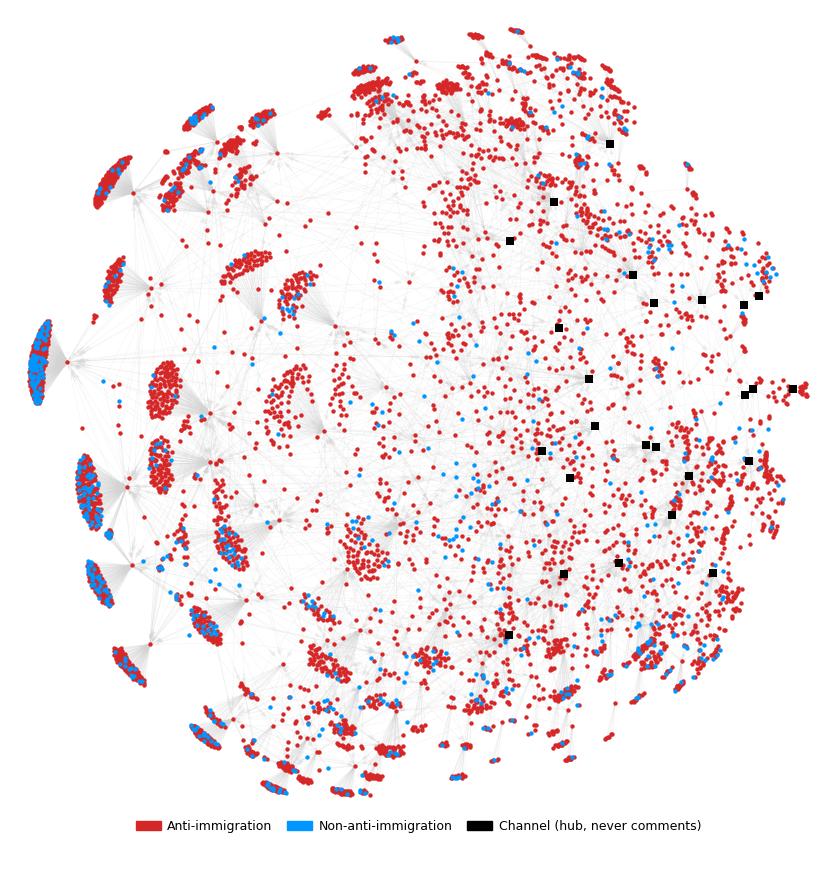

[draw_opinion_network] nodes=2857, edges=3752


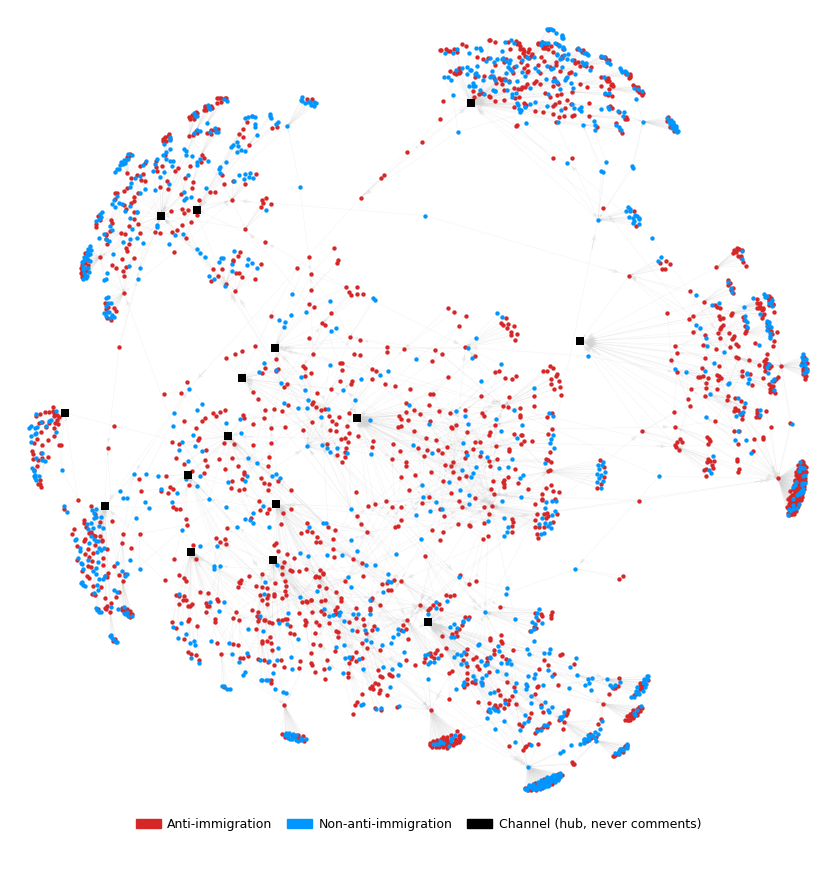

In [15]:
COLOR_MAP = {
    "Anti-immigration": "#d62728",
    "Non-anti-immigration": "#0096FF",
}
HUB_COLOR = "black"

def build_plot_network(stance):
    G = build_stance_subnetwork(stance)
    for node, data in G.nodes(data=True):
        if data.get("node_type") == "hub":
            data["cls"] = "Hub"
    return G

def compact_circular_layout(
    G, seed=42, iterations=300, spring_strength=0.42,
    tail_quantile=0.68, centre_expansion=0.92,
    centre_pull=3.5, network_scale=0.84
):
    layout_graph = G.to_undirected().copy()
    layout_graph.remove_edges_from(nx.selfloop_edges(layout_graph))

    for source, target in layout_graph.edges():
        layout_graph[source][target]["layout_weight"] = 1.0

    anchor = "__CENTRE_ANCHOR__"
    layout_graph.add_node(anchor)

    hubs = [node for node in G if G.nodes[node].get("cls") == "Hub"]
    for node in hubs:
        layout_graph.add_edge(anchor, node, layout_weight=centre_pull)

    k = spring_strength / math.sqrt(max(G.number_of_nodes(), 1))
    rng = np.random.default_rng(seed)
    initial = {node: rng.normal(0.0, 0.20, 2) for node in layout_graph}
    initial[anchor] = np.array([0.0, 0.0])

    raw = nx.spring_layout(
        layout_graph,
        pos=initial,
        fixed=[anchor],
        seed=seed,
        iterations=iterations,
        k=k,
        weight="layout_weight",
        center=(0.0, 0.0),
    )
    raw.pop(anchor)

    nodes = list(G)
    xy = np.array([raw[node] for node in nodes], dtype=float)
    xy -= xy.mean(axis=0)

    covariance = np.cov(xy.T)
    _, eigenvectors = np.linalg.eigh(covariance)
    eigenvectors = eigenvectors[:, ::-1]
    xy = xy @ eigenvectors

    x_std, y_std = xy[:, 0].std(), xy[:, 1].std()
    target_std = math.sqrt(max(x_std, 1e-10) * max(y_std, 1e-10))
    xy[:, 0] *= target_std / x_std
    xy[:, 1] *= target_std / y_std

    radii = np.linalg.norm(xy, axis=1)
    positive = radii[radii > 0]
    reference = max(np.quantile(positive, tail_quantile), 1e-10)
    compressed = reference * np.tanh(radii / reference)
    xy *= np.divide(compressed, radii, out=np.ones_like(radii), where=radii > 0)[:, None]

    radii = np.linalg.norm(xy, axis=1)
    normalised = radii / radii.max()
    filled = normalised ** centre_expansion
    xy *= np.divide(filled, normalised, out=np.ones_like(filled), where=normalised > 0)[:, None]

    hub_idx = [i for i, node in enumerate(nodes) if G.nodes[node].get("cls") == "Hub"]
    xy -= xy[hub_idx].mean(axis=0)

    max_radius = np.linalg.norm(xy, axis=1).max()
    if max_radius > 0:
        xy /= max_radius
    xy *= network_scale

    return {node: tuple(xy[i]) for i, node in enumerate(nodes)}

def draw_edges(G, pos, ax):
    nx.draw_networkx_edges(
        G, pos, ax=ax, edge_color="lightgrey",
        width=0.4, alpha=0.25, arrows=False
    )

    edge_list = list(G.edges())
    source_xy = np.array([pos[source] for source, _ in edge_list])
    target_xy = np.array([pos[target] for _, target in edge_list])

    tip = source_xy + (target_xy - source_xy) * 0.95
    delta = (target_xy - source_xy) * 0.001

    ax.quiver(
        tip[:, 0], tip[:, 1], delta[:, 0], delta[:, 1],
        angles="xy", scale_units="xy", scale=0.02,
        width=0.0015, headwidth=4, headlength=5,
        headaxislength=4.5, color="lightgrey",
        alpha=0.4, pivot="tip"
    )

def draw_opinion_network(G, savepath=None):
    print(f"[draw_opinion_network] nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")
    pos = compact_circular_layout(G)

    fig = plt.figure(figsize=(8.2, 8.8), facecolor="white")
    grid = fig.add_gridspec(2, 1, height_ratios=[16, 0.9], hspace=-0.02)
    ax = fig.add_subplot(grid[0])
    legend_ax = fig.add_subplot(grid[1])

    draw_edges(G, pos, ax)

    for cls in CLASSES:
        nodes = [
            node for node, data in G.nodes(data=True)
            if data.get("node_type") == "user" and data.get("cls") == cls
        ]
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodes, ax=ax,
            node_shape="o", node_color=COLOR_MAP[cls],
            node_size=10, edgecolors=COLOR_MAP[cls], linewidths=0
        )

    hubs = [node for node, data in G.nodes(data=True) if data.get("node_type") == "hub"]
    nx.draw_networkx_nodes(
        G, pos, nodelist=hubs, ax=ax,
        node_shape="s", node_color=HUB_COLOR,
        node_size=35, edgecolors=HUB_COLOR, linewidths=0
    )

    xy = np.array(list(pos.values()))
    x_min, x_max = xy[:, 0].min(), xy[:, 0].max()
    y_min, y_max = xy[:, 1].min(), xy[:, 1].max()
    x_pad = max(x_max - x_min, 1e-6) * 0.025
    y_pad = max(y_max - y_min, 1e-6) * 0.025
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    legend_ax.axis("off")
    legend_ax.legend(
        handles=[
            mpatches.Patch(color=COLOR_MAP["Anti-immigration"], label="Anti-immigration"),
            mpatches.Patch(color=COLOR_MAP["Non-anti-immigration"], label="Non-anti-immigration"),
            mpatches.Patch(color="black", label="Channel (hub, never comments)"),
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=3,
        frameon=False,
        fontsize=9,
        handletextpad=0.5,
        columnspacing=1.2,
        borderaxespad=0,
    )

    fig.subplots_adjust(left=0.002, right=0.998, top=0.998, bottom=0.002)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", pad_inches=0.01, facecolor="white")

    return fig, ax

G_right = build_plot_network("Right")
G_mainstream = build_plot_network("Mainstream")

draw_opinion_network(G_right, savepath="opinion_network_right.png")
plt.show()

draw_opinion_network(G_mainstream, savepath="opinion_network_mainstream.png")
plt.show()


In [ ]:
def build_video_subgraph(video_id, mode="main"):
    source_edges = keep_edges if mode == "main" else edges
    allowed_classes = valid_classes if mode == "main" else None

    sub_edges = [
        (source, target)
        for source, target, vid, _ in source_edges
        if vid == video_id
    ]

    G = nx.DiGraph()
    G.add_node(
        ("VIDEO", video_id),
        node_type="hub",
        stance=video_stance_map[video_id],
        cls=None,
    )

    for source, target in sub_edges:
        for node in (source, target):
            if isinstance(node, tuple):
                continue
            cls = user_class.get(node)
            if allowed_classes is None or cls in allowed_classes:
                G.add_node(node, node_type="user", cls=cls)

    G.add_edges_from(sub_edges)
    G.remove_nodes_from(list(nx.isolates(G)))
    return G

def compute_video_ei_table(mode="main"):
    rows = []

    for video_id, stance in video_stance_map.items():
        G = build_video_subgraph(video_id, mode)
        results, global_ei = ei_index(G)
        title = df.loc[df["video_id"] == video_id, "title"].iloc[0]

        row = {
            "video_id": video_id,
            "title": title,
            "video_stance": stance,
            "nodes": G.number_of_nodes(),
            "edges": G.number_of_edges(),
        }

        for cls in CLASSES:
            row[f"{cls}_internal"] = results[cls]["internal"]
            row[f"{cls}_external"] = results[cls]["external"]
            row[f"{cls}_EI"] = round(results[cls]["class_EI"], 3)

        row["global_EI"] = round(global_ei, 3)
        rows.append(row)

    return (
        pd.DataFrame(rows)
          .sort_values(["video_stance", "nodes"], ascending=[True, False])
          .reset_index(drop=True)
    )

video_ei_main = compute_video_ei_table("main")
video_ei_full = compute_video_ei_table("full")

video_ei_main.to_csv("../SRQ3 Regression/video_ei_index_main.csv", index=False)
video_ei_full.to_csv("../SRQ3 Regression/video_ei_index_full.csv", index=False)

print("=== Per-video E-I Index — MAIN network (Anti vs Non-anti only) ===")
video_ei_main


=== Per-video E-I Index — MAIN network (Anti vs Non-anti only) ===


,video_id,title,video_stance,nodes,edges,Anti-immigration_internal,Anti-immigration_external,Anti-immigration_EI,Non-anti-immigration_internal,Non-anti-immigration_external,Non-anti-immigration_EI,global_EI
0,FcP3nnQzXhc,UK: Migrants in the Channel | ARTE.tv Documentary,Mainstream,438,524,330,52,-0.728,20,122,0.718,-0.336
1,u8cg5hhHJlA,Europe's Migration Tragedy: Life and death in ...,Mainstream,425,472,104,143,0.158,93,132,0.173,0.165
2,zTs3PDEkB2w,UK immigration: What the numbers really show,Mainstream,411,495,81,155,0.314,151,108,-0.166,0.063
3,MEhC0oM1aAo,Going Undercover as a Migrant in Brexit Britain,Mainstream,338,402,128,77,-0.249,35,162,0.645,0.189
4,WdEscW9olFg,UK net migration down 48% year on year | BBC News,Mainstream,246,436,179,71,-0.432,7,179,0.925,0.147
5,DSbWRvKyIuE,Refugees to face 20-year wait to settle perman...,Mainstream,235,319,147,51,-0.485,9,112,0.851,0.022
6,191CuNRGoos,Stranded: Exposing the UK’s immigration scamme...,Mainstream,156,182,41,50,0.099,30,61,0.341,0.220
7,ciY1zFgSskY,Nigel Farage reacts to 'UK being colonised by ...,Mainstream,123,150,41,37,-0.051,1,71,0.972,0.440
8,XFH8aGBjA6U,UK home secretary announces some migrants will...,Mainstream,114,163,50,64,0.123,6,43,0.755,0.313
9,A-zFK_LPxJI,'Nigel Farage can sod off' says Home Secretary...,Mainstream,105,128,51,39,-0.133,9,29,0.526,0.062
